In [ ]:
# 1. IMPORT LIBRARIES

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, MaxPooling1D,
    Flatten, Input
)
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# =========================================================
# 2. LOAD DATA
# =========================================================
df = pd.read_csv("jm1.csv")

df.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10885 non-null  float64
 1   v(g)               10885 non-null  float64
 2   ev(g)              10885 non-null  float64
 3   iv(g)              10885 non-null  float64
 4   n                  10885 non-null  float64
 5   v                  10885 non-null  float64
 6   l                  10885 non-null  float64
 7   d                  10885 non-null  float64
 8   i                  10885 non-null  float64
 9   e                  10885 non-null  float64
 10  b                  10885 non-null  float64
 11  t                  10885 non-null  float64
 12  lOCode             10885 non-null  int64  
 13  lOComment          10885 non-null  int64  
 14  lOBlank            10885 non-null  int64  
 15  locCodeAndComment  10885 non-null  int64  
 16  uniq_Op            108

In [ ]:
# =========================================================
# 3. DATA CLEANING
# =========================================================

# Convert object columns to numeric
object_cols = df.select_dtypes(include=["object"]).columns
for col in object_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert target to numeric
df["defects"] = df["defects"].astype(int)

# Check class distribution
print("\nClass distribution:")
print(df["defects"].value_counts())
print(df["defects"].value_counts(normalize=True) * 100)


Class distribution:
defects
0    8779
1    2106
Name: count, dtype: int64
defects
0    80.652274
1    19.347726
Name: proportion, dtype: float64


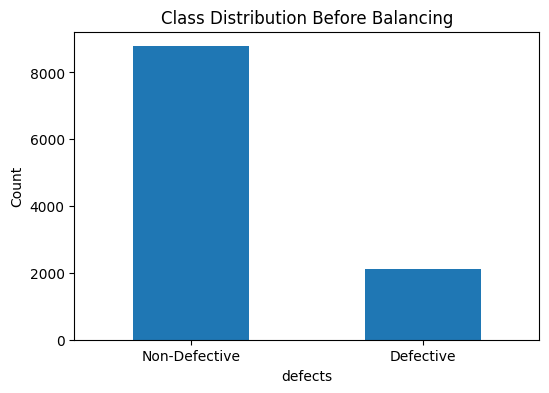

In [ ]:
# Class distribution plot
plt.figure(figsize=(6, 4))
df["defects"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Non-Defective", "Defective"], rotation=0)
plt.title("Class Distribution Before Balancing")
plt.ylabel("Count")
plt.show()

In [ ]:
# 4. SEPARATE FEATURES AND TARGET

X = df.drop(columns=["defects"])
y = df["defects"]

feature_names = X.columns.tolist()
n_features = X.shape[1]

print("Number of features:", n_features)
print("Feature names:", feature_names)

Number of features: 21
Feature names: ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']


In [ ]:
# 5. TRAIN-TEST SPLIT
#    Keep final test set untouched until the end

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8708, 21)
Test shape: (2177, 21)


In [ ]:
# 6. PREPROCESSING
#    Fit on training only to avoid leakage

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Impute first
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale second
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaNs in X_test_scaled:", np.isnan(X_test_scaled).sum())

NaNs in X_train_scaled: 0
NaNs in X_test_scaled: 0


In [ ]:
# 7. APPLY SMOTE TO TRAINING DATA ONLY

smote = SMOTE(random_state=RANDOM_STATE)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Class distribution after SMOTE:
defects
0    7023
1    7023
Name: count, dtype: int64


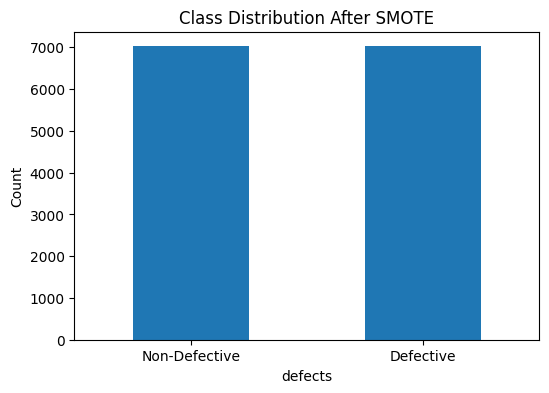

In [ ]:
# Plot balanced training data
plt.figure(figsize=(6, 4))
pd.Series(y_train_resampled).value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Non-Defective", "Defective"], rotation=0)
plt.title("Class Distribution After SMOTE")
plt.ylabel("Count")
plt.show()

In [ ]:
# 8. TRAIN-VALIDATION SPLIT FOR DEEP LEARNING
#    Validation comes from the balanced training data

X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train_resampled,
    y_train_resampled,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_resampled
)

print("DL train shape:", X_train_dl.shape)
print("DL validation shape:", X_val_dl.shape)

DL train shape: (11236, 21)
DL validation shape: (2810, 21)


In [ ]:
# 9. RESHAPE FOR CNN
#    Conv1D expects (samples, timesteps, channels)

X_train_cnn = X_train_dl.reshape(X_train_dl.shape[0], X_train_dl.shape[1], 1)
X_val_cnn = X_val_dl.reshape(X_val_dl.shape[0], X_val_dl.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("CNN train shape:", X_train_cnn.shape)
print("CNN val shape:", X_val_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

CNN train shape: (11236, 21, 1)
CNN val shape: (2810, 21, 1)
CNN test shape: (2177, 21, 1)


In [ ]:
# 10. EVALUATION FUNCTION

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Evaluate binary classification results.
    y_prob should be probability for class 1.
    """
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob)
    }
    return results

In [ ]:
# 11. DECISION TREE WITH STRATIFIED K-FOLD GRID SEARCH

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_param_grid = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train_resampled, y_train_resampled)

best_dt = dt_grid.best_estimator_
print("Best DT params:", dt_grid.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best DT params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# DT predictions
y_pred_dt = best_dt.predict(X_test_scaled)
y_prob_dt = best_dt.predict_proba(X_test_scaled)[:, 1]

dt_results = evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)
dt_results

{'Model': 'Decision Tree',
 'Accuracy': 0.7326596233348645,
 'Precision': 0.34122287968441817,
 'Recall': 0.41092636579572445,
 'F1-Score': 0.3728448275862069,
 'AUC-ROC': np.float64(0.5958512111849973),
 'Log Loss': 9.375630800831328}

In [ ]:
# 12. RANDOM FOREST WITH STRATIFIED K-FOLD GRID SEARCH

rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_resampled, y_train_resampled)

best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# RF predictions
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

rf_results = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.7831878732200276,
 'Precision': 0.43410852713178294,
 'Recall': 0.3990498812351544,
 'F1-Score': 0.4158415841584158,
 'AUC-ROC': np.float64(0.7381140467159761),
 'Log Loss': 0.6060975061575968}

        Feature  Importance
0           loc    0.130656
14      lOBlank    0.091692
3         iv(g)    0.090386
20  branchCount    0.066085
1          v(g)    0.065670
12       lOCode    0.046810
17    uniq_Opnd    0.040715
16      uniq_Op    0.040423
8             i    0.038570
7             d    0.037150


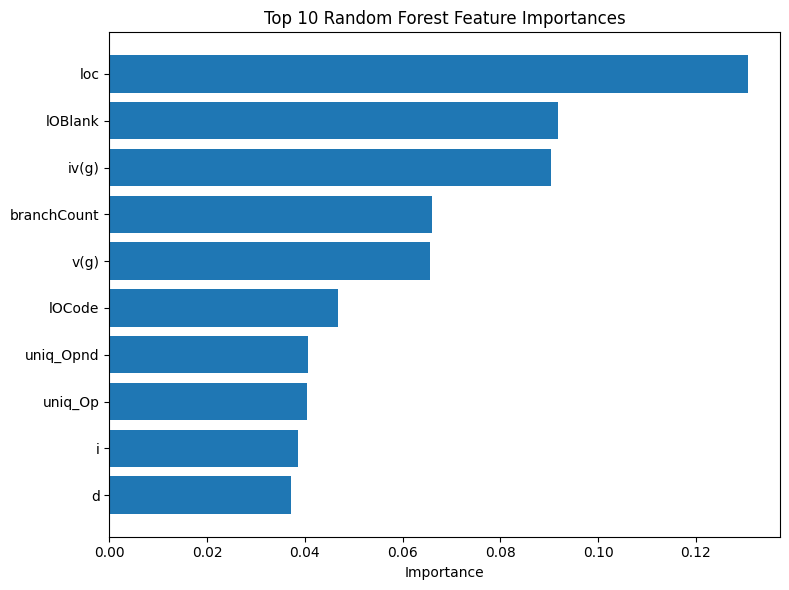

In [ ]:
# 13. FEATURE IMPORTANCE FROM RANDOM FOREST

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance.head(10))

plt.figure(figsize=(8, 6))
plt.barh(rf_importance["Feature"].head(10)[::-1],
         rf_importance["Importance"].head(10)[::-1])
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# 14. ANN MODEL

def build_ann(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

ann_model = build_ann(X_train_dl.shape[1])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_ann = ann_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6429 - loss: 0.6392 - val_accuracy: 0.6544 - val_loss: 0.6283
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6608 - loss: 0.6217 - val_accuracy: 0.6626 - val_loss: 0.6215
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6653 - loss: 0.6140 - val_accuracy: 0.6626 - val_loss: 0.6140
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6699 - loss: 0.6125 - val_accuracy: 0.6676 - val_loss: 0.6105
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6762 - loss: 0.6075 - val_accuracy: 0.6722 - val_loss: 0.6073
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6719 - loss: 0.6073 - val_accuracy: 0.6719 - val_loss: 0.6049
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6790 - loss: 0.6021 - val_accuracy: 0.6790 - val_loss: 0.6038
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6791 - loss: 0.6026 - val_accuracy: 0.

In [ ]:
# ANN predictions
y_prob_ann = ann_model.predict(X_test_scaled).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

ann_results = evaluate_model("ANN", y_test, y_pred_ann, y_prob_ann)
ann_results

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'Model': 'ANN',
 'Accuracy': 0.7032613688562241,
 'Precision': 0.34610123119015046,
 'Recall': 0.6009501187648456,
 'F1-Score': 0.4392361111111111,
 'AUC-ROC': np.float64(0.7185225815527624),
 'Log Loss': 0.5864233895680947}

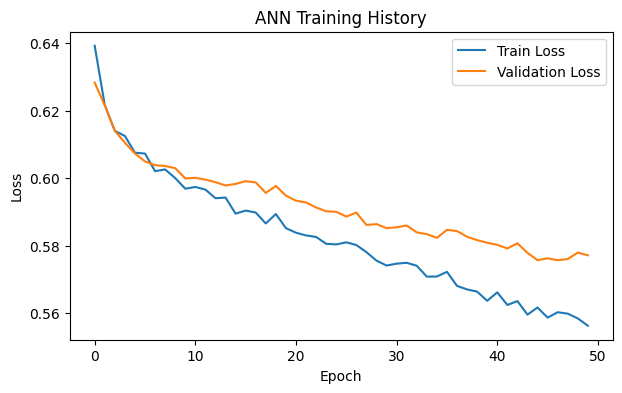

In [ ]:
# Plot ANN learning curves
plt.figure(figsize=(7, 4))
plt.plot(history_ann.history["loss"], label="Train Loss")
plt.plot(history_ann.history["val_loss"], label="Validation Loss")
plt.title("ANN Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# 15. 1D-CNN MODEL

def build_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(filters=32, kernel_size=2, activation="relu"),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(filters=64, kernel_size=2, activation="relu"),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_cnn((X_train_cnn.shape[1], 1))

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_dl,
    validation_data=(X_val_cnn, y_val_dl),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6419 - loss: 0.6401 - val_accuracy: 0.6399 - val_loss: 0.6343
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6549 - loss: 0.6289 - val_accuracy: 0.6537 - val_loss: 0.6290
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6662 - loss: 0.6209 - val_accuracy: 0.6566 - val_loss: 0.6253
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6658 - loss: 0.6197 - val_accuracy: 0.6591 - val_loss: 0.6211
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6657 - loss: 0.6162 - val_accuracy: 0.6594 - val_loss: 0.6216
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6695 - loss: 0.6138 - val_accuracy: 0.6623 - val_loss: 0.6187
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6718 - loss: 0.6116 - val_accuracy: 0.6619 - val_loss: 0.6162
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6673 - loss: 0.6100 - val_accuracy: 0

In [ ]:
# CNN predictions
y_prob_cnn = cnn_model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

cnn_results = evaluate_model("1D-CNN", y_test, y_pred_cnn, y_prob_cnn)
cnn_results

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


{'Model': '1D-CNN',
 'Accuracy': 0.6605420303169499,
 'Precision': 0.31161137440758296,
 'Recall': 0.6247030878859857,
 'F1-Score': 0.4158102766798419,
 'AUC-ROC': np.float64(0.6924240743646486),
 'Log Loss': 0.6401010638810661}

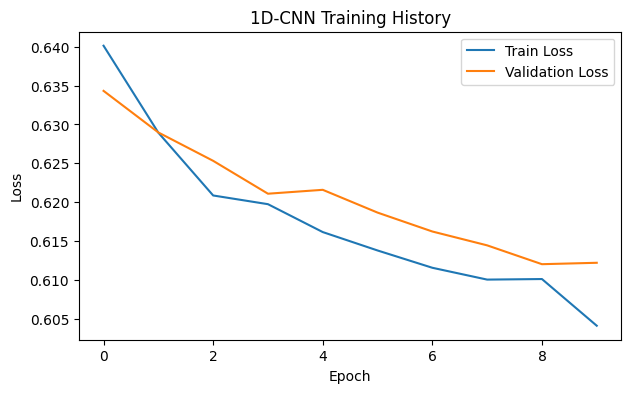

In [ ]:
# Plot CNN learning curves
plt.figure(figsize=(7, 4))
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("1D-CNN Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# 16. SOFT VOTING ENSEMBLE
#    Equal weights as

ensemble_prob = (y_prob_dt + y_prob_rf + y_prob_ann + y_prob_cnn) / 4
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

ensemble_results = evaluate_model(
    "Soft Voting Ensemble",
    y_test,
    ensemble_pred,
    ensemble_prob
)

ensemble_results

{'Model': 'Soft Voting Ensemble',
 'Accuracy': 0.752411575562701,
 'Precision': 0.38247011952191234,
 'Recall': 0.45605700712589076,
 'F1-Score': 0.4160346695557963,
 'AUC-ROC': np.float64(0.7387815917194661),
 'Log Loss': 0.5106234357543562}

In [ ]:
# 16. WEIGHTED SOFT VOTING ENSEMBLE

# Use validation F1 (or test F1 if validation not stored)
w_dt = dt_results["F1-Score"]
w_rf = rf_results["F1-Score"]
w_ann = ann_results["F1-Score"]
w_cnn = cnn_results["F1-Score"]

# Normalise weights
weight_sum = w_dt + w_rf + w_ann + w_cnn

w_dt /= weight_sum
w_rf /= weight_sum
w_ann /= weight_sum
w_cnn /= weight_sum

print("Weights:")
print({
    "DT": round(w_dt, 4),
    "RF": round(w_rf, 4),
    "ANN": round(w_ann, 4),
    "CNN": round(w_cnn, 4)
})

Weights:
{'DT': 0.2219, 'RF': 0.2644, 'ANN': 0.2639, 'CNN': 0.2498}


In [ ]:
# Combine probabilities

ensemble_prob = (
    w_dt * y_prob_dt +
    w_rf * y_prob_rf +
    w_ann * y_prob_ann +
    w_cnn * y_prob_cnn
)

In [ ]:
ensemble_results = evaluate_model(
    "Weighted Soft Voting Ensemble",
    y_test,
    ensemble_pred,
    ensemble_prob
)

print(ensemble_results)

{'Model': 'Weighted Soft Voting Ensemble', 'Accuracy': 0.7565457050987597, 'Precision': 0.3907815631262525, 'Recall': 0.46318289786223277, 'F1-Score': 0.42391304347826086, 'AUC-ROC': np.float64(0.7410919602421829), 'Log Loss': 0.5097637127108455}


In [ ]:
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

In [ ]:
# 17. COMBINE RESULTS INTO ONE TABLE

results_df = pd.DataFrame([
    dt_results,
    rf_results,
    ann_results,
    cnn_results,
    ensemble_results
])

results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Log Loss
0,ANN,0.693156,0.341055,0.629454,0.442404,0.712941,0.598081
1,Soft Voting Ensemble,0.755627,0.389222,0.463183,0.422993,0.737798,0.512261
2,1D-CNN,0.652733,0.310734,0.653207,0.421133,0.693604,0.639795
3,Random Forest,0.783188,0.434109,0.399050,0.415842,0.738114,0.606098
4,Decision Tree,0.732660,0.341223,0.410926,0.372845,0.595851,9.375631


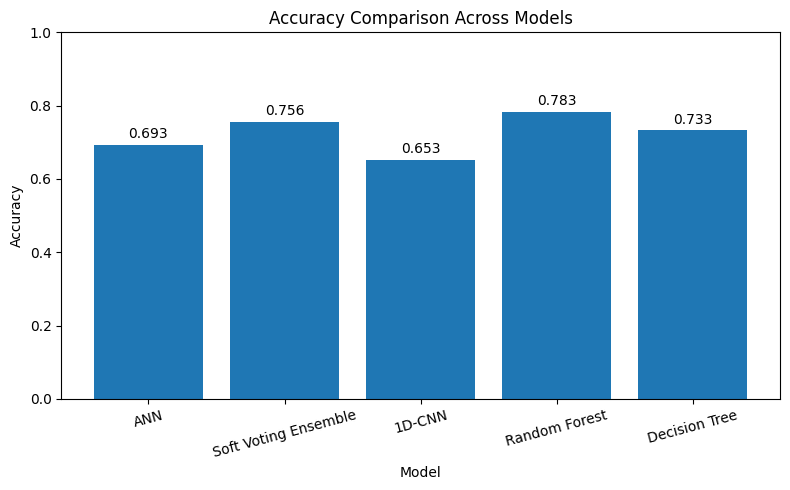

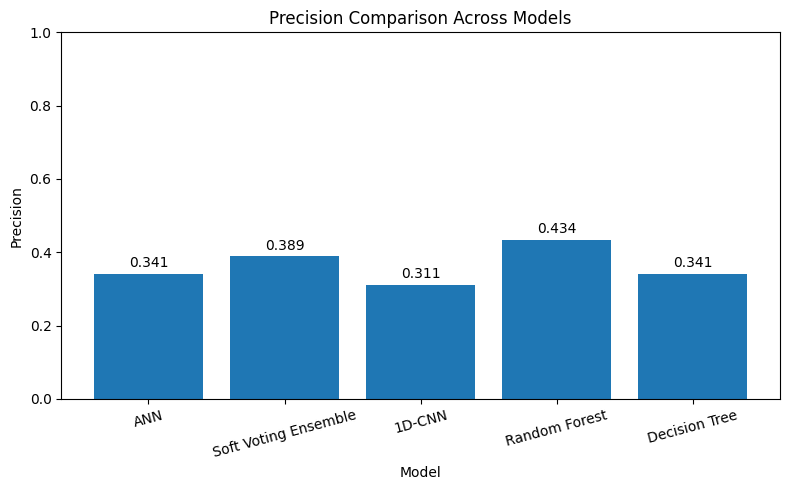

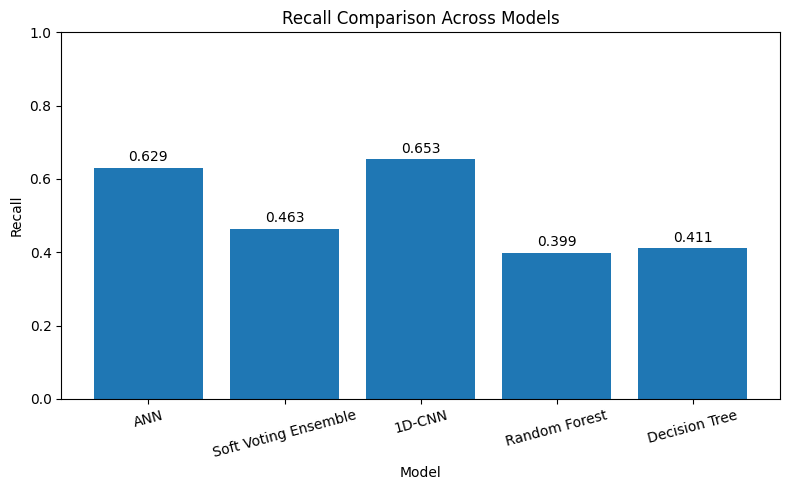

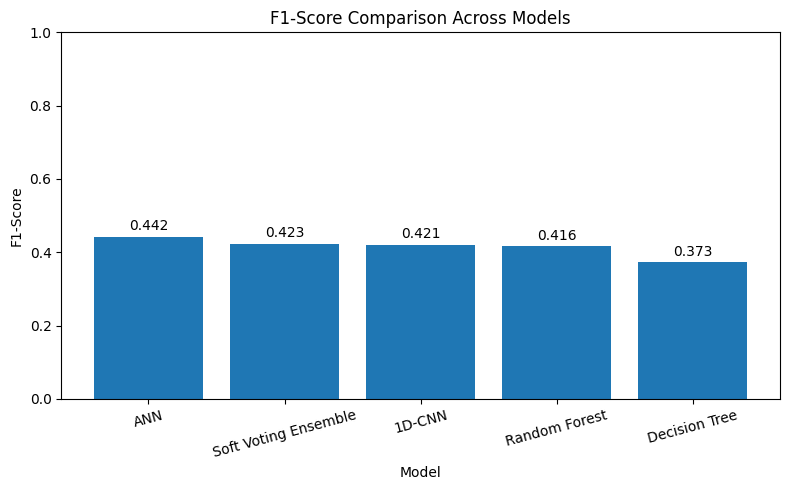

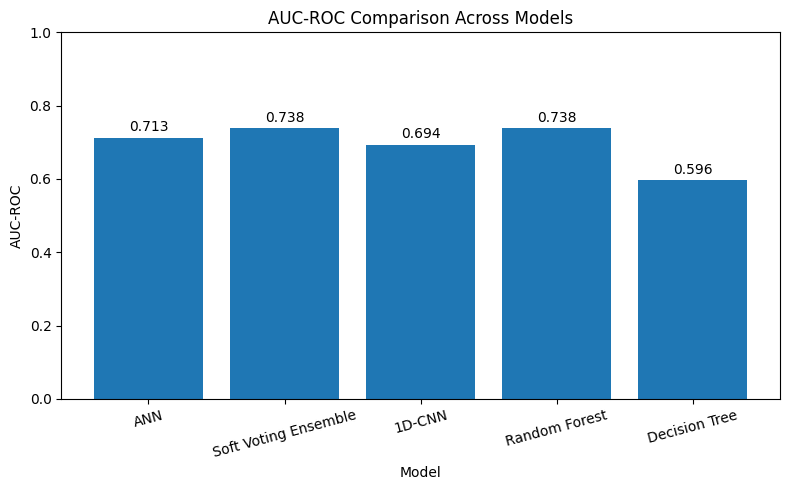

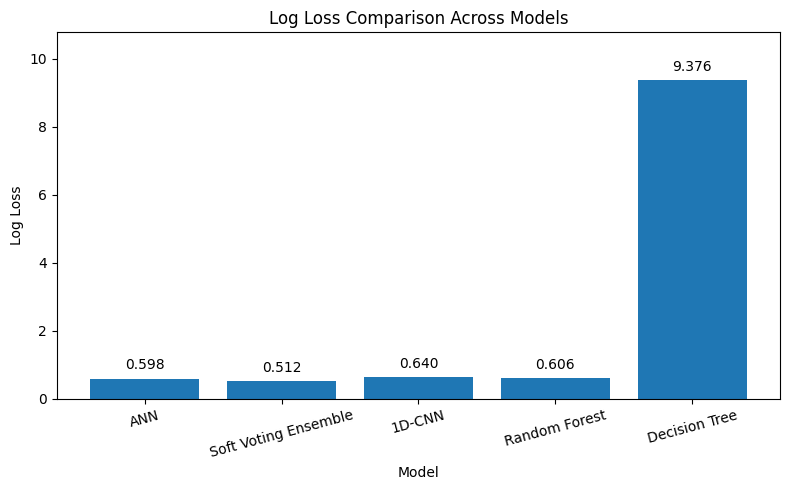

In [ ]:
# 18. PLOT EACH METRIC ACROSS ALL MODELS

import matplotlib.pyplot as plt

# Keep model order as it appears in results_df
plot_df = results_df.copy()

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC",
    "Log Loss"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(plot_df["Model"], plot_df[metric])

    plt.title(f"{metric} Comparison Across Models")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=15)

    # Use a sensible y-axis
    if metric != "Log Loss":
        plt.ylim(0, 1)
    else:
        plt.ylim(0, plot_df[metric].max() * 1.15)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.01 if metric != "Log Loss" else plot_df[metric].max() * 0.02),
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

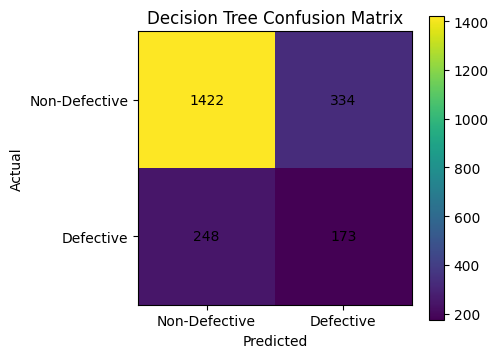

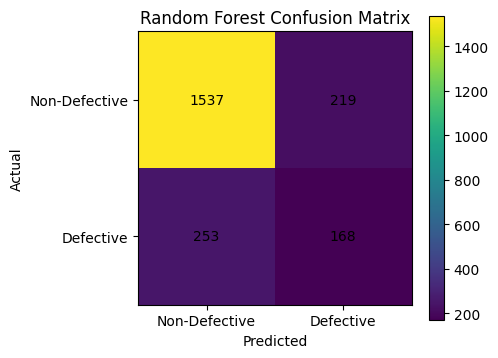

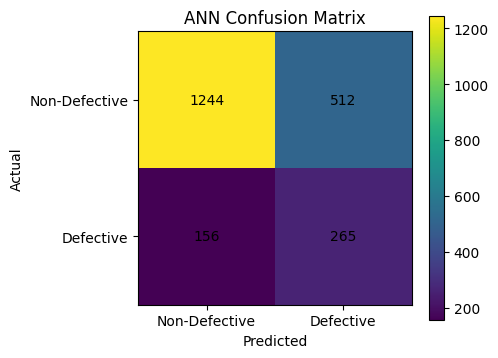

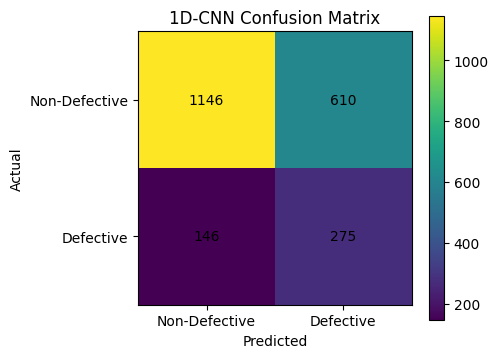

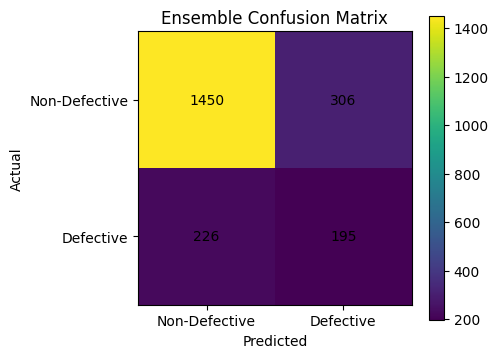

In [ ]:
# 19. CONFUSION MATRICES

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Non-Defective", "Defective"])
    plt.yticks([0, 1], ["Non-Defective", "Defective"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test, y_pred_dt, "Decision Tree Confusion Matrix")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
plot_conf_matrix(y_test, y_pred_ann, "ANN Confusion Matrix")
plot_conf_matrix(y_test, y_pred_cnn, "1D-CNN Confusion Matrix")
plot_conf_matrix(y_test, ensemble_pred, "Ensemble Confusion Matrix")

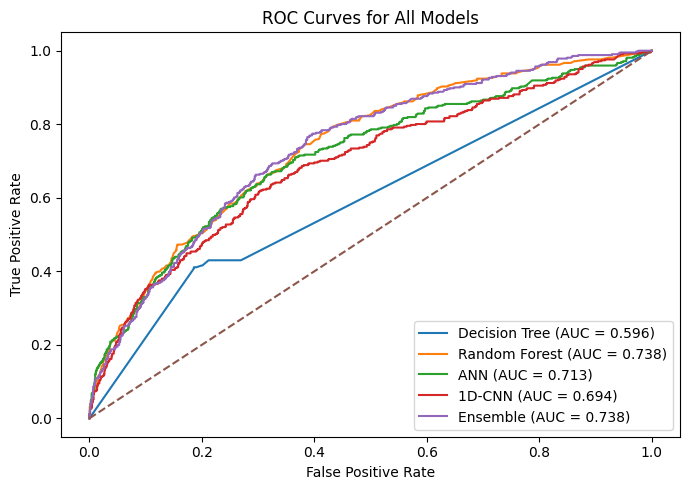

In [ ]:
# 20. ROC CURVES

plt.figure(figsize=(7, 5))

for name, probs in [
    ("Decision Tree", y_prob_dt),
    ("Random Forest", y_prob_rf),
    ("ANN", y_prob_ann),
    ("1D-CNN", y_prob_cnn),
    ("Ensemble", ensemble_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 21. PRINT CLASSIFICATION REPORTS

print("\nDecision Tree Report")
print(classification_report(y_test, y_pred_dt, digits=4))

print("\nRandom Forest Report")
print(classification_report(y_test, y_pred_rf, digits=4))

print("\nANN Report")
print(classification_report(y_test, y_pred_ann, digits=4))

print("\n1D-CNN Report")
print(classification_report(y_test, y_pred_cnn, digits=4))

print("\nEnsemble Report")
print(classification_report(y_test, ensemble_pred, digits=4))


Decision Tree Report
              precision    recall  f1-score   support

           0     0.8515    0.8098    0.8301      1756
           1     0.3412    0.4109    0.3728       421

    accuracy                         0.7327      2177
   macro avg     0.5964    0.6104    0.6015      2177
weighted avg     0.7528    0.7327    0.7417      2177


Random Forest Report
              precision    recall  f1-score   support

           0     0.8587    0.8753    0.8669      1756
           1     0.4341    0.3990    0.4158       421

    accuracy                         0.7832      2177
   macro avg     0.6464    0.6372    0.6414      2177
weighted avg     0.7766    0.7832    0.7797      2177


ANN Report
              precision    recall  f1-score   support

           0     0.8886    0.7084    0.7883      1756
           1     0.3411    0.6295    0.4424       421

    accuracy                         0.6932      2177
   macro avg     0.6148    0.6689    0.6154      2177
weighted avg     0